# DDPM from Scratch: 2D Swiss Roll Tutorial

This notebook walks through the complete implementation of a **Denoising Diffusion Probabilistic Model (DDPM)** on a 2D Swiss Roll distribution.

We will cover three layers:
1. **Physical intuition** — what diffusion actually does
2. **Mathematical formulation** — the key equations
3. **Engineering implementation** — working PyTorch code

Reference: [Ho et al., *Denoising Diffusion Probabilistic Models*, NeurIPS 2020](https://arxiv.org/abs/2006.11239)

In [1]:
import sys
sys.path.insert(0, "..")

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from tqdm.notebook import tqdm

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

---
## 1. The Swiss Roll Dataset

We use a 2D Swiss Roll as our target distribution. Its spiral structure is
simple enough to train quickly yet complex enough to verify that the model
has genuinely learned the data manifold.

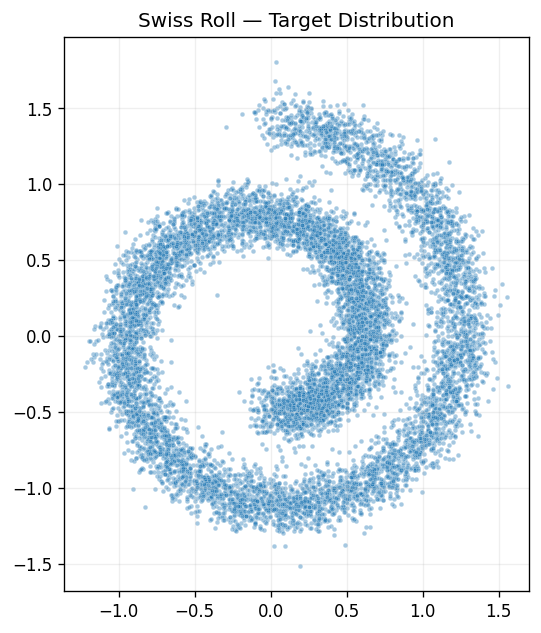

In [5]:
def sample_batch(size, noise=1.0):
    """Sample a 2D Swiss Roll point cloud."""
    x, _ = make_swiss_roll(size, noise=noise)
    return x[:, [0, 2]] / 10.0

data = sample_batch(10_000)
dataset = torch.tensor(data, dtype=torch.float32)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(data[:, 0], data[:, 1], alpha=0.4, s=8,
           edgecolors="white", linewidths=0.3)
ax.set_title("Swiss Roll — Target Distribution")
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)
plt.show()

---
## 2. Noise Schedule

The forward process gradually adds Gaussian noise controlled by a variance
schedule $\{\beta_t\}_{t=1}^{T}$.

We define:
- $\alpha_t = 1 - \beta_t$
- $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$

A **sigmoid schedule** maps evenly-spaced values through a sigmoid to
produce betas that start small and grow smoothly.

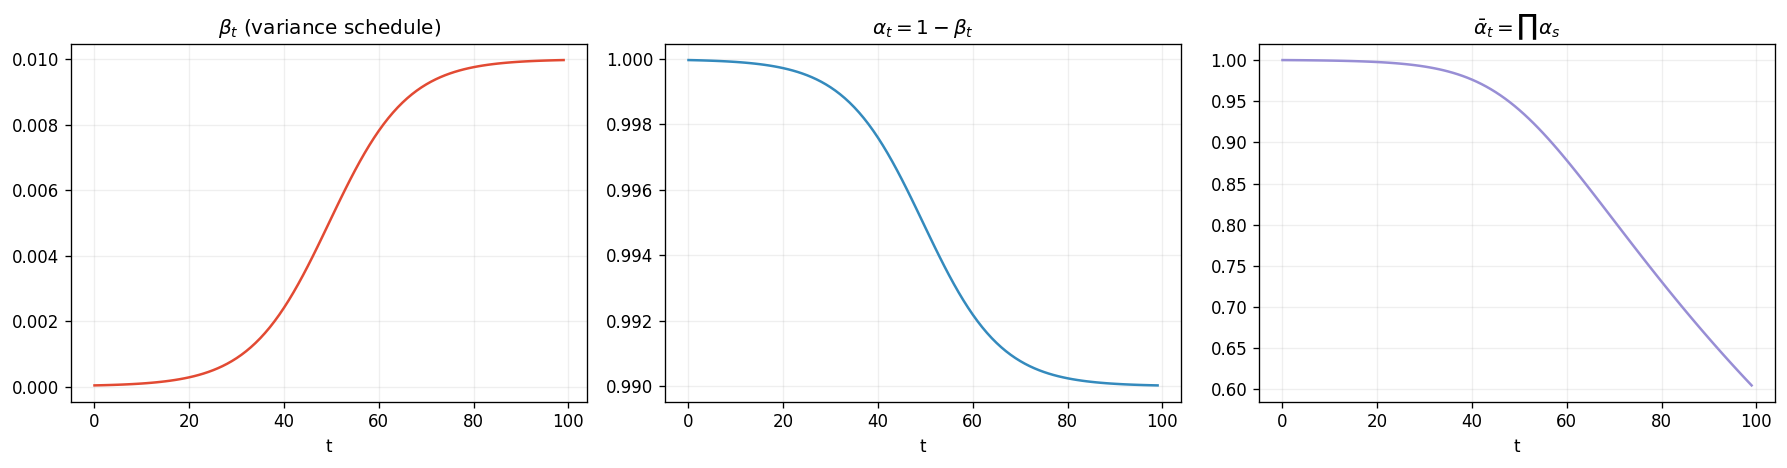

In [6]:
n_steps = 100
beta_start = 1e-5
beta_end = 1e-2

betas = torch.sigmoid(torch.linspace(-6, 6, n_steps)) * (beta_end - beta_start) + beta_start
alphas = 1 - betas
alphas_bar = torch.cumprod(alphas, dim=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(betas.numpy(), color="#E24A33")
axes[0].set_title(r"$\beta_t$ (variance schedule)")
axes[0].set_xlabel("t")

axes[1].plot(alphas.numpy(), color="#348ABD")
axes[1].set_title(r"$\alpha_t = 1 - \beta_t$")
axes[1].set_xlabel("t")

axes[2].plot(alphas_bar.numpy(), color="#988ED5")
axes[2].set_title(r"$\bar{\alpha}_t = \prod \alpha_s$")
axes[2].set_xlabel("t")

for ax in axes:
    ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

---
## 3. Forward Diffusion Process

### Step-by-step form
$$q(x_t \mid x_{t-1}) = \mathcal{N}\big(x_t;\, \sqrt{1-\beta_t}\, x_{t-1},\; \beta_t I\big)$$

### Closed-form (skip to any $t$)
$$q(x_t \mid x_0) = \mathcal{N}\big(x_t;\, \sqrt{\bar{\alpha}_t}\, x_0,\; (1-\bar{\alpha}_t) I\big)$$

Using the reparameterisation trick:
$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

This lets us jump directly to any timestep without iterating.

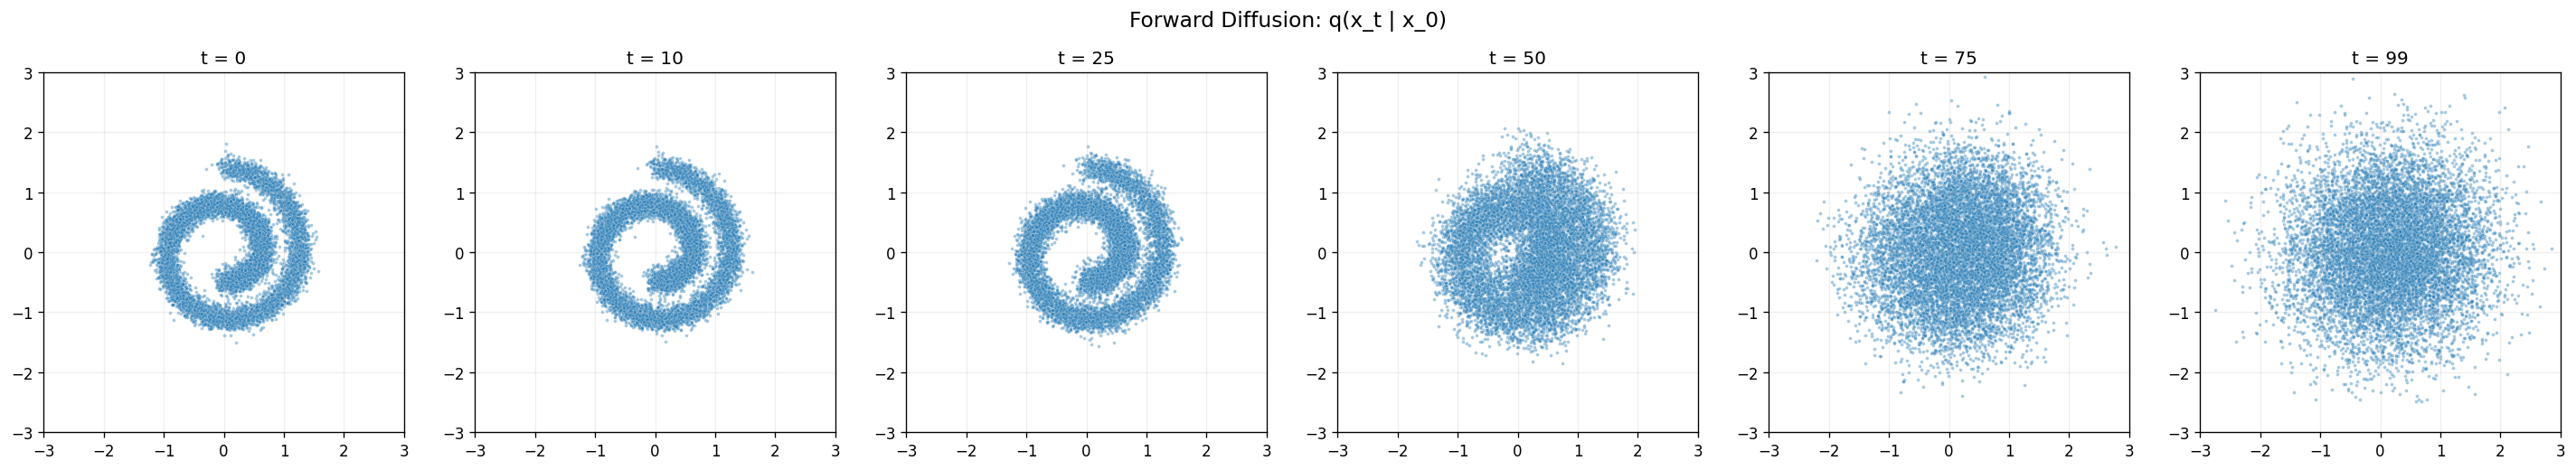

In [7]:
def q_sample(x0, t, noise=None):
    """Forward diffusion: sample x_t from q(x_t | x_0)."""
    if noise is None:
        noise = torch.randn_like(x0)
    alpha_bar_t = alphas_bar[t].unsqueeze(1)
    return torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * noise

# Visualise forward diffusion at selected timesteps
show_steps = [0, 10, 25, 50, 75, 99]
fig, axes = plt.subplots(1, len(show_steps), figsize=(4 * len(show_steps), 4))

for ax, t in zip(axes, show_steps):
    t_batch = torch.full((dataset.shape[0],), t, dtype=torch.long)
    x_t = q_sample(dataset, t_batch)
    pts = x_t.numpy()
    ax.scatter(pts[:, 0], pts[:, 1], alpha=0.4, s=5, edgecolors="white", linewidths=0.2)
    ax.set_title(f"t = {t}")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

fig.suptitle("Forward Diffusion: q(x_t | x_0)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

**Observation:** As $t$ increases, the structured Swiss Roll gradually dissolves
into isotropic Gaussian noise. By $t = T$ the original structure is completely
destroyed — this is exactly what we want.

---
## 4. The Denoising Model

We need a neural network $\varepsilon_\theta(x_t, t)$ to predict the noise
that was added at step $t$.

For 2D data a simple MLP is sufficient (no U-Net needed). We condition on
the timestep $t$ via **learned embedding vectors** that multiplicatively
scale each layer's output.

Architecture: `2 → 128 → 128 → 128 → 2` with softplus activations.

In [9]:
class ConditionalLinear(nn.Module):
    """Linear layer with timestep-conditioned multiplicative gating."""

    def __init__(self, in_features, out_features, num_steps):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.embed = nn.Embedding(num_steps, out_features)
        self.embed.weight.data.uniform_()

    def forward(self, x, t):
        out = self.linear(x)
        gamma = self.embed(t)
        return gamma.view(-1, out.size(-1)) * out


class ConditionalModel(nn.Module):
    """MLP noise predictor eps_theta(x_t, t)."""

    def __init__(self, n_steps, data_dim=2, hidden_dim=128):
        super().__init__()
        self.lin1 = ConditionalLinear(data_dim, hidden_dim, n_steps)
        self.lin2 = ConditionalLinear(hidden_dim, hidden_dim, n_steps)
        self.lin3 = ConditionalLinear(hidden_dim, hidden_dim, n_steps)
        self.lin4 = nn.Linear(hidden_dim, data_dim)

    def forward(self, x, t):
        x = F.softplus(self.lin1(x, t))
        x = F.softplus(self.lin2(x, t))
        x = F.softplus(self.lin3(x, t))
        return self.lin4(x)


model = ConditionalModel(n_steps)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 72,066


---
## 5. Training Loss

The DDPM simplified loss is:

$$L_{\text{simple}}(\theta) = \mathbb{E}_{t,\, x_0,\, \varepsilon} \Big[\| \varepsilon - \varepsilon_\theta\big(\sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \varepsilon,\; t\big) \|^2 \Big]$$

For each mini-batch we:
1. Sample a random timestep $t$ per data point
2. Sample noise $\varepsilon \sim \mathcal{N}(0, I)$
3. Compute $x_t$ via the closed-form forward equation
4. Predict $\varepsilon_\theta(x_t, t)$ and compute MSE against true $\varepsilon$

In [10]:
def noise_estimation_loss(model, x0):
    """Simplified DDPM training loss."""
    batch_size = x0.shape[0]
    t = torch.randint(0, n_steps, (batch_size,)).long()
    eps = torch.randn_like(x0)

    x_t = (
        x0 * torch.sqrt(alphas_bar[t]).unsqueeze(1)
        + eps * torch.sqrt(1 - alphas_bar[t]).unsqueeze(1)
    )
    predicted = model(x_t, t)
    return (eps - predicted).square().mean()

---
## 6. Training

We train with Adam (lr=1e-3), batch size 128, gradient clipping at 1.0.

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 128
n_epochs = 1000

epoch_losses = []

for epoch in tqdm(range(n_epochs), desc="Training"):
    perm = torch.randperm(dataset.shape[0])
    batch_losses = []

    for i in range(0, dataset.shape[0], batch_size):
        batch = dataset[perm[i : i + batch_size]]
        loss = noise_estimation_loss(model, batch)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    avg = sum(batch_losses) / len(batch_losses)
    epoch_losses.append(avg)

print(f"Final loss: {epoch_losses[-1]:.6f}")

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Final loss: 0.727144


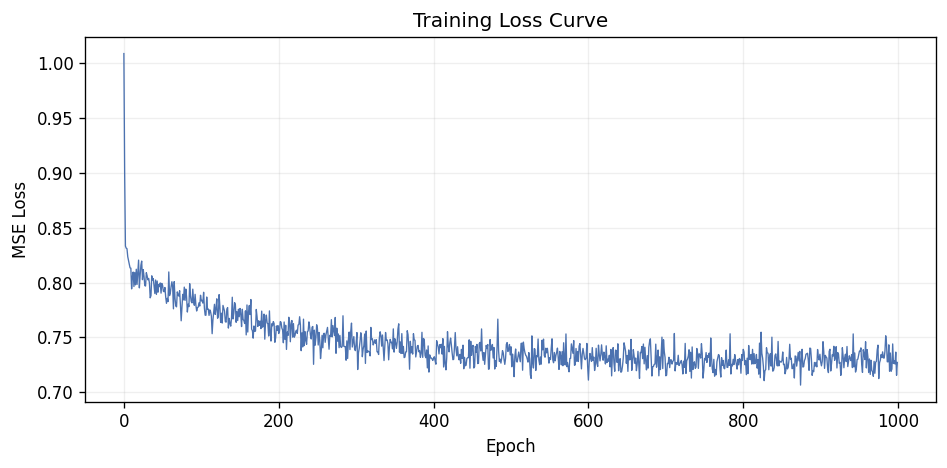

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epoch_losses, linewidth=0.8, color="#4C72B0")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training Loss Curve")
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

---
## 7. Reverse (Denoising) Process

To generate new samples we run the reverse Markov chain:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \varepsilon_\theta(x_t, t) \right) + \sigma_t z$$

where $z \sim \mathcal{N}(0, I)$ and $\sigma_t = \sqrt{\beta_t}$.

Starting from pure noise $x_T \sim \mathcal{N}(0, I)$, we iterate
$T \to T{-}1 \to \cdots \to 0$ to arrive at a clean sample.

In [13]:
@torch.no_grad()
def p_sample(model, x_t, t):
    """Single reverse denoising step."""
    t_tensor = torch.full((x_t.shape[0],), t, dtype=torch.long)

    eps_theta = model(x_t, t_tensor)
    eps_coeff = betas[t] / torch.sqrt(1 - alphas_bar[t])
    mean = (1.0 / torch.sqrt(alphas[t])) * (x_t - eps_coeff * eps_theta)

    if t > 0:
        z = torch.randn_like(x_t)
        return mean + torch.sqrt(betas[t]) * z
    return mean


@torch.no_grad()
def p_sample_loop(model, shape):
    """Full reverse chain: x_T -> x_0."""
    x = torch.randn(shape)
    trajectory = [x.clone()]
    for t in reversed(range(n_steps)):
        x = p_sample(model, x, t)
        trajectory.append(x.clone())
    return trajectory

---
## 8. Generate & Visualise

Let's generate 10 000 new points and compare with the real distribution.

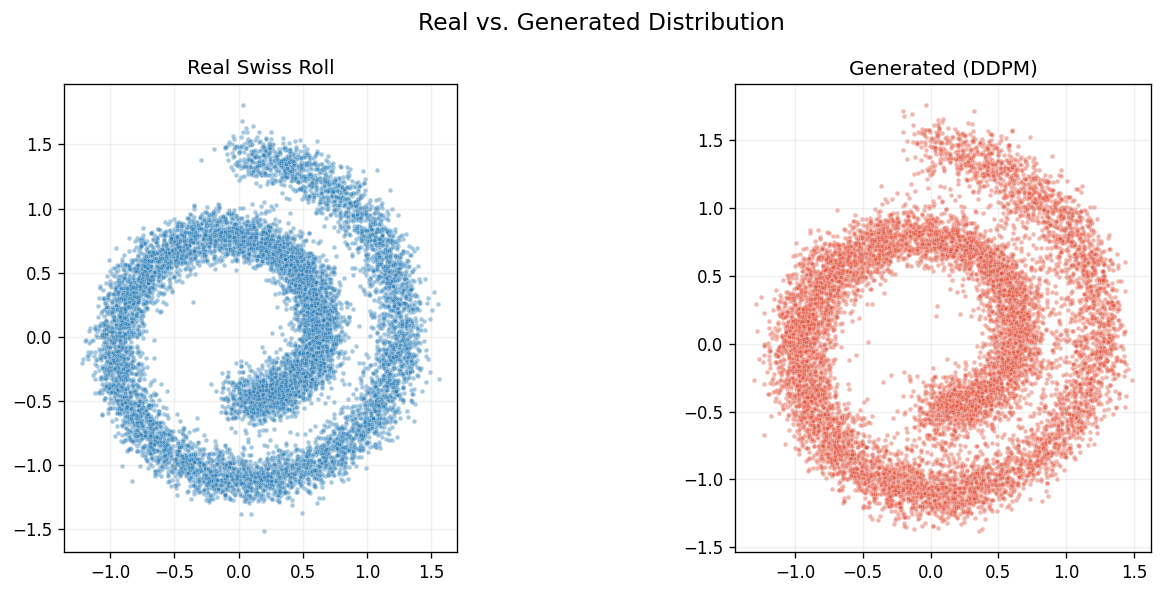

In [14]:
model.eval()
trajectory = p_sample_loop(model, dataset.shape)
generated = trajectory[-1].numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(data[:, 0], data[:, 1], alpha=0.4, s=8,
                edgecolors="white", linewidths=0.3)
axes[0].set_title("Real Swiss Roll")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.2)

axes[1].scatter(generated[:, 0], generated[:, 1], alpha=0.4, s=8,
                edgecolors="white", linewidths=0.3, color="#E24A33")
axes[1].set_title("Generated (DDPM)")
axes[1].set_aspect("equal")
axes[1].grid(True, alpha=0.2)

fig.suptitle("Real vs. Generated Distribution", fontsize=14)
fig.tight_layout()
plt.show()

### Reverse Process Snapshots

Watch the noise gradually organise into the Swiss Roll structure.

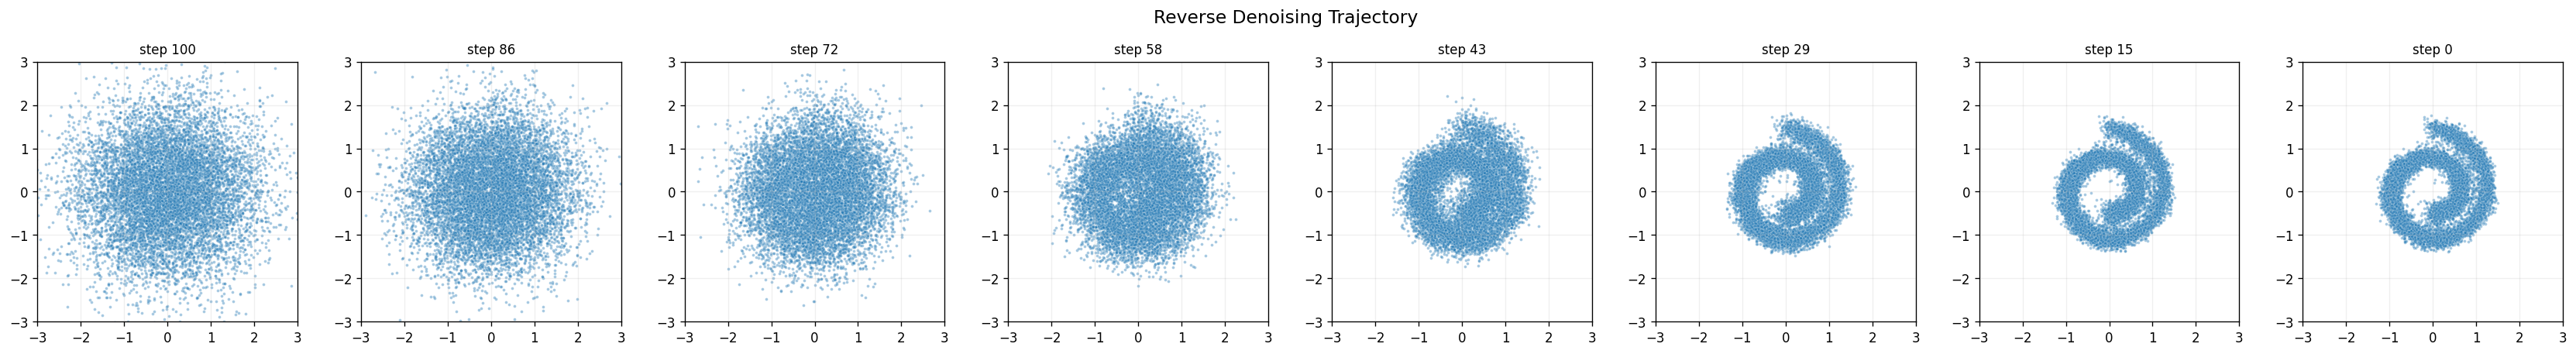

In [15]:
show_indices = np.linspace(0, len(trajectory) - 1, 8, dtype=int)
fig, axes = plt.subplots(1, len(show_indices), figsize=(3.5 * len(show_indices), 3.5))

for ax, idx in zip(axes, show_indices):
    pts = trajectory[idx].numpy()
    remaining = len(trajectory) - 1 - idx
    ax.scatter(pts[:, 0], pts[:, 1], alpha=0.4, s=5,
               edgecolors="white", linewidths=0.2)
    ax.set_title(f"step {remaining}", fontsize=10)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

fig.suptitle("Reverse Denoising Trajectory", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 9. Summary

### What we built

| Component | Purpose |
|---|---|
| **Noise Schedule** | Controls how fast information is destroyed ($\beta_t$, $\alpha_t$, $\bar{\alpha}_t$) |
| **Forward Process** | Adds noise: $x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \varepsilon$ |
| **Denoising Model** | MLP $\varepsilon_\theta(x_t, t)$ predicts the noise |
| **Training Loss** | $L = \|\varepsilon - \varepsilon_\theta(x_t, t)\|^2$ |
| **Reverse Process** | Iteratively removes noise to generate new samples |

### Key takeaways

1. The forward process needs **no learning** — it is a fixed Markov chain.
2. The closed-form formula lets us sample any $x_t$ in $O(1)$ during training.
3. The model only needs to predict **noise**, not the clean data directly.
4. Even a tiny MLP can learn a non-trivial 2D distribution with ~100 steps.
5. The same principles scale to images (replace MLP with U-Net, use more steps).